In [74]:
import torch
from torch import nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [75]:
def dropout_layer(X, dropout):
  assert 0 <= dropout <= 1
  if dropout == 1:
    return torch.zeros_like(X)
  mask = (torch.rand(X.shape) > dropout).float()
  return mask * X / (1.0 - dropout)

In [76]:
X = torch.arange(16, dtype=torch.float32).reshape((2, 8))
print('dropout_p = 0: ', dropout_layer(X, 0))
print('dropout_p = 0.5: ', dropout_layer(X, 0.5))
print('dropout_p = 1: ', dropout_layer(X, 1))

dropout_p = 0:  tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
dropout_p = 0.5:  tensor([[ 0.,  2.,  0.,  0.,  8., 10.,  0., 14.],
        [ 0.,  0.,  0.,  0.,  0., 26., 28., 30.]])
dropout_p = 1:  tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]])


In [77]:
class DropoutMLPScratch(nn.Module):
  def __init__(self, num_inputs, num_outputs, num_hidden_1, num_hidden_2, dropout_1, dropout_2):
    super(DropoutMLPScratch, self).__init__()
    self.lin1 = nn.Linear(num_inputs, num_hidden_1)
    self.lin2 = nn.Linear(num_hidden_1, num_hidden_2)
    self.lin3 = nn.Linear(num_hidden_2, num_outputs)
    self.relu = nn.ReLU()
    self.dropout1 = nn.Dropout(dropout_1)
    self.dropout2 = nn.Dropout(dropout_2)

  def forward(self, X):
    X = X.view(X.size(0), -1)

    H1 = self.relu(self.lin1(X))
    H1 = self.dropout1(H1)

    H2 = self.relu(self.lin2(H1))
    H2 = self.dropout1(H2)
    out = self.lin3(H2)
    return out


In [78]:
hparams = {
    'num_inputs': 784,
    'num_ouputs': 10,
    'num_hidden_1': 256,
    'num_hidden_2': 256,
    'dropout_1': 0.5,
    'dropout_2': 0.5,
    'lr': 0.1,
    'batch_size': 256,
    'epochs': 10,
}

In [79]:
from modulefinder import test
transform = transforms.ToTensor()
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=hparams['batch_size'], shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=hparams['batch_size'], shuffle=False)

In [80]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DropoutMLPScratch(
    num_inputs=784,
    num_outputs=hparams['num_ouputs'],
    num_hidden_1=hparams['num_hidden_1'],
    num_hidden_2=hparams['num_hidden_2'],
    dropout_1=hparams['dropout_1'],
    dropout_2=hparams['dropout_2']
).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=hparams['lr'])

In [81]:
train_losses = []
train_accuracies = []
test_accuracies = []
for epoch in range(hparams['epochs']):
  model.train()
  train_loss = 0
  correct = 0
  total = 0

  for X, y in train_loader:
    X, y = X.to(device), y.to(device)
    optimizer.zero_grad()
    outputs = model(X)
    loss = criterion(outputs, y)
    loss.backward()
    optimizer.step()
    train_loss += loss.item()
    _, predicted = outputs.max(1)
    total += y.size(0)
    correct += predicted.eq(y).sum().item()

  train_acc = 100 * correct / total
  avg_loss = train_loss / len(train_loader)
  model.eval()
  test_correct = 0
  test_total = 0

  with torch.no_grad():
    for X, y in test_loader:
      X, y = X.to(device), y.to(device)
      outputs = model(X)
      _, predicted = outputs.max(1)
      test_total += y.size(0)
      test_correct += predicted.eq(y).sum().item()

  test_acc = 100 * test_correct / test_total
  train_losses.append(avg_loss)
  train_accuracies.append(train_acc)
  test_accuracies.append(test_acc)
  print(f"Epoch [{epoch+1}/{hparams['epochs']}]"
    f"Loss: {train_loss:.4f}"
    f"Train Acc: {train_acc:.2f}%"
    f"Test Acc: {test_acc:.2f}%"
  )


Epoch [1/10]Loss: 272.5368Train Acc: 58.19%Test Acc: 74.50%
Epoch [2/10]Loss: 162.1127Train Acc: 75.22%Test Acc: 78.97%
Epoch [3/10]Loss: 137.6985Train Acc: 79.26%Test Acc: 80.63%
Epoch [4/10]Loss: 124.5001Train Acc: 81.22%Test Acc: 83.10%
Epoch [5/10]Loss: 116.8113Train Acc: 82.45%Test Acc: 83.38%
Epoch [6/10]Loss: 111.5855Train Acc: 83.18%Test Acc: 84.13%
Epoch [7/10]Loss: 107.4594Train Acc: 83.83%Test Acc: 84.62%
Epoch [8/10]Loss: 104.5310Train Acc: 84.21%Test Acc: 84.66%
Epoch [9/10]Loss: 100.8566Train Acc: 84.69%Test Acc: 85.41%
Epoch [10/10]Loss: 97.9405Train Acc: 85.14%Test Acc: 85.20%


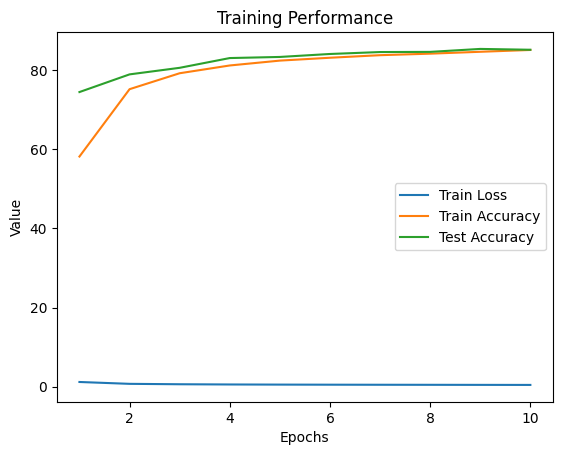

In [82]:
import matplotlib.pyplot as plt

epochs = range(1, hparams['epochs'] + 1)

plt.figure()

plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, test_accuracies, label='Test Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Training Performance')
plt.legend()

plt.show()

In [83]:
class DropoutMLP(nn.Module):
    def __init__(self, num_inputs, num_outputs, num_hiddens_1, num_hiddens_2,
                 dropout_1, dropout_2):
        super().__init__()

        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(num_inputs, num_hiddens_1),
            nn.ReLU(),
            nn.Dropout(dropout_1),

            nn.Linear(num_hiddens_1, num_hiddens_2),
            nn.ReLU(),
            nn.Dropout(dropout_2),

            nn.Linear(num_hiddens_2, num_outputs)
        )

    def forward(self, X):
        return self.net(X)

In [84]:
model_1 = DropoutMLP(
    num_inputs=hparams['num_inputs'],
    num_outputs=hparams['num_ouputs'],
    num_hiddens_1=hparams['num_hidden_1'],
    num_hiddens_2=hparams['num_hidden_2'],
    dropout_1=hparams['dropout_1'],
    dropout_2=hparams['dropout_2']
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_1.parameters(), lr=hparams['lr'])
X = torch.randn(256, 1, 28, 28).to(device)
out = model_1(X)
print(out.shape)

torch.Size([256, 10])


In [85]:
train_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(hparams['epochs']):
    model_1.train()
    train_loss = 0
    correct = 0
    total = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model_1(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += y.size(0)
        correct += predicted.eq(y).sum().item()

    train_acc = 100 * correct / total
    avg_loss = train_loss / len(train_loader)

    # Evaluation
    model_1.eval()
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            outputs = model_1(X)
            _, predicted = outputs.max(1)
            test_total += y.size(0)
            test_correct += predicted.eq(y).sum().item()

    test_acc = 100 * test_correct / test_total

    # Store metrics
    train_losses.append(avg_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"Epoch [{epoch+1}/{hparams['epochs']}] "
          f"Loss: {avg_loss:.4f} "
          f"Train Acc: {train_acc:.2f}% "
          f"Test Acc: {test_acc:.2f}%")

Epoch [1/10] Loss: 1.1710 Train Acc: 57.55% Test Acc: 73.34%
Epoch [2/10] Loss: 0.6820 Train Acc: 75.55% Test Acc: 78.10%
Epoch [3/10] Loss: 0.5788 Train Acc: 79.49% Test Acc: 80.33%
Epoch [4/10] Loss: 0.5274 Train Acc: 81.25% Test Acc: 82.01%
Epoch [5/10] Loss: 0.4964 Train Acc: 82.53% Test Acc: 83.81%
Epoch [6/10] Loss: 0.4704 Train Acc: 83.41% Test Acc: 83.66%
Epoch [7/10] Loss: 0.4542 Train Acc: 83.92% Test Acc: 83.33%
Epoch [8/10] Loss: 0.4396 Train Acc: 84.39% Test Acc: 84.76%
Epoch [9/10] Loss: 0.4301 Train Acc: 84.61% Test Acc: 85.12%
Epoch [10/10] Loss: 0.4215 Train Acc: 85.05% Test Acc: 85.17%


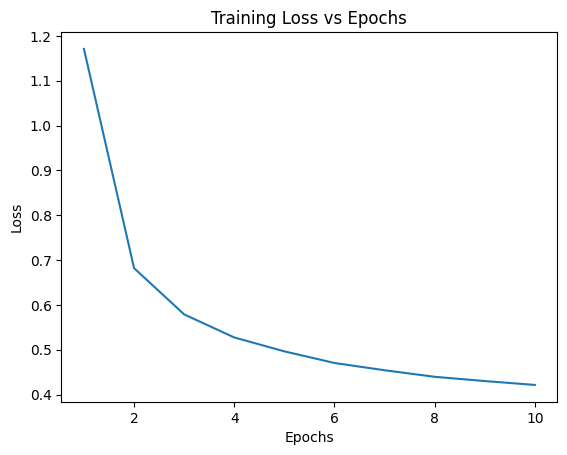

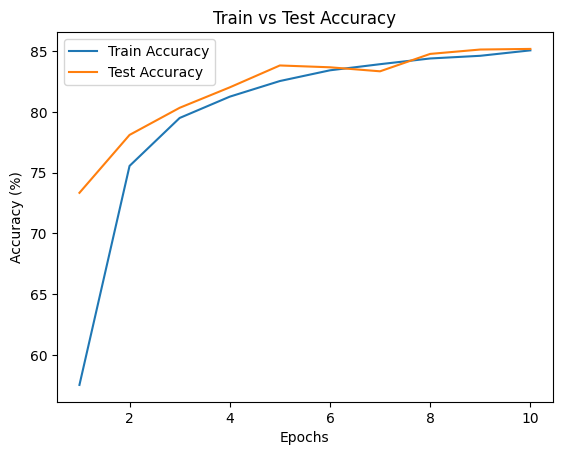

In [86]:
import matplotlib.pyplot as plt

epochs = range(1, hparams['epochs'] + 1)

# 📉 Loss Plot
plt.figure()
plt.plot(epochs, train_losses)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss vs Epochs')
plt.show()

# 📈 Accuracy Plot
plt.figure()
plt.plot(epochs, train_accuracies)
plt.plot(epochs, test_accuracies)
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Train vs Test Accuracy')
plt.legend(['Train Accuracy', 'Test Accuracy'])
plt.show()